# Olist Revenue Forecast for the Dashboard (v2) -> some code adjusted due to compute limits (marked with "perf downgrade" comments)
## 1) Next-7-day trend + prediction interval  2) Projected month-end close (pacing)

### What v1 got fixed

| Problem | v1 | v2 |
|---|---|---|
| **Prediction interval was miscalibrated** (target 80% -> actual 60%) | Residual quantiles from the validation set, applied directly | **Split Conformal Prediction** - theoretically guaranteed coverage |
| **Evaluated on a single split** | Tested on only one May-August window | **Rolling-origin CV** - origin date rolled forward 7 days at a time, ~30 repeated evaluations |
| **31 separate models trained** | Independent model per h, ~500 rows each | **One global model with h as a feature** - trained on ~17,000 rows at once |
| **Assumed "RF is best"** | RandomForest fixed with no justification | 3 baselines + 3 tree models + Prophet (optional), **compared under identical conditions and auto-selected** |
| **Pacing uncertainty was unrealistic** | Bootstrap assuming independent daily errors | **Directly estimate the error distribution of the cumulative sum itself** via conformal (no independence assumption needed) |
| Features mostly lag/MA | 6 | Added **engineered features**: day-of-week profile, momentum, expected level, etc. |

### Why a global model with h as a feature
Splitting models by h means each model only sees ~500 rows. Putting h in as a feature lets a
single model train on ~17,000 rows while learning the pattern itself - "confidence in recent
values fades as the horizon gets further out."
This notebook compares both approaches **under the same CV** and lets the data decide which is better.

In [14]:
# =========================================================
# Cell 1 - Libraries & data load
# =========================================================
import os, warnings
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ===== Only this path needs to match your environment =====
PATH = r'C:\Users\Peter\Desktop\Brazilian E-Commerce Public Dataset by Olist'

orders = pd.read_csv(os.path.join(PATH, "olist_orders_dataset.csv"))
items  = pd.read_csv(os.path.join(PATH, "olist_order_items_dataset.csv"))

for c in ["order_purchase_timestamp", "order_approved_at",
          "order_delivered_carrier_date", "order_delivered_customer_date",
          "order_estimated_delivery_date"]:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

order_revenue = (
    items.groupby("order_id")
         .agg(revenue=("price", "sum"), freight=("freight_value", "sum"))
         .reset_index()
)
order_revenue["total_revenue"] = order_revenue["revenue"] + order_revenue["freight"]

df = orders.merge(order_revenue, on="order_id", how="inner")
df = df[df["order_status"] == "delivered"].copy()
df["order_date"] = df["order_purchase_timestamp"].dt.date

daily = (
    df.groupby("order_date")
      .agg(order_count=("order_id", "nunique"), daily_revenue=("total_revenue", "sum"))
      .reset_index()
)
daily["order_date"] = pd.to_datetime(daily["order_date"])
daily = daily.sort_values("order_date").reset_index(drop=True)

full_range = pd.date_range(daily["order_date"].min(), daily["order_date"].max(), freq="D")
daily_full = (
    daily[["order_date", "order_count", "daily_revenue"]]
    .set_index("order_date").reindex(full_range, fill_value=0).reset_index()
)
daily_full.columns = ["order_date", "order_count", "daily_revenue"]

cust_daily = df.groupby("order_date").agg(n_customers=("customer_id", "nunique")).reset_index()
cust_daily["order_date"] = pd.to_datetime(cust_daily["order_date"])

sell_daily = items.merge(df[["order_id", "order_date"]], on="order_id", how="inner")
sell_daily = sell_daily.groupby("order_date")["seller_id"].nunique().reset_index()
sell_daily.columns = ["order_date", "n_sellers"]
sell_daily["order_date"] = pd.to_datetime(sell_daily["order_date"])

daily_full = (daily_full.merge(cust_daily, on="order_date", how="left")
                        .merge(sell_daily, on="order_date", how="left"))
daily_full[["n_customers", "n_sellers"]] = daily_full[["n_customers", "n_sellers"]].fillna(0)

print("daily_full:", daily_full.shape)
print(daily_full.tail(3).to_string(index=False))

daily_full: (714, 5)
order_date  order_count  daily_revenue  n_customers  n_sellers
2018-08-27           66        6111.61         66.0       60.0
2018-08-28           39        4121.22         39.0       35.0
2018-08-29           11        1762.70         11.0       11.0


In [15]:
# =========================================================
# Cell 2 - Training window + calendar/holidays/Black Friday
# =========================================================
START_DATE, END_DATE = "2017-01-05", "2018-08-21"

base = daily_full[(daily_full["order_date"] >= START_DATE) &
                  (daily_full["order_date"] <= END_DATE)].copy().reset_index(drop=True)
print("Days in window:", len(base), "| Days with R$0 revenue:", (base["daily_revenue"] == 0).sum())

def easter_date(year):
    a, b, c = year % 19, year // 100, year % 100
    d, e = b // 4, b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    hh = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    l = (32 + 2 * e + 2 * i - hh - k) % 7
    m = (a + 11 * hh + 22 * l) // 451
    month = (hh + l - 7 * m + 114) // 31
    day = ((hh + l - 7 * m + 114) % 31) + 1
    return date(year, month, day)

FIXED_HOLIDAYS = [(1, 1), (4, 21), (5, 1), (9, 7), (10, 12), (11, 2), (11, 15), (12, 25)]

def brazil_holidays(year):
    days = {date(year, m, d) for m, d in FIXED_HOLIDAYS}
    e = easter_date(year)
    days |= {e - timedelta(days=47), e - timedelta(days=2), e + timedelta(days=60)}
    return days

def black_friday(year):
    d0 = date(year, 11, 1)
    thu = [d0 + timedelta(days=i) for i in range(30)
           if (d0 + timedelta(days=i)).month == 11 and (d0 + timedelta(days=i)).weekday() == 3]
    return thu[3] + timedelta(days=1)

years = sorted(base["order_date"].dt.year.unique())
holiday_set = set().union(*[brazil_holidays(y) for y in years])
bf_set = {black_friday(y) for y in years}
# Black Friday week (day 0 to +5): mitigates the single-observation problem
bf_week = set()
for y in years:
    bf = black_friday(y)
    bf_week |= {bf + timedelta(days=i) for i in range(6)}

base["dayofweek"] = base["order_date"].dt.dayofweek
base["month"]     = base["order_date"].dt.month
base["day"]       = base["order_date"].dt.day
base["is_weekend"] = base["dayofweek"].isin([5, 6]).astype(int)
base["day_index"]  = (base["order_date"] - base["order_date"].min()).dt.days
base["is_holiday"] = base["order_date"].dt.date.isin(holiday_set).astype(int)
base["is_bf"]      = base["order_date"].dt.date.isin(bf_set).astype(int)
base["is_bf_week"] = base["order_date"].dt.date.isin(bf_week).astype(int)
base["dom_pos"]    = base["day"] / base["order_date"].dt.days_in_month   # progress through the month

print("Holidays:", base["is_holiday"].sum(), "days | Black Friday week:", base["is_bf_week"].sum(), "days")

Days in window: 594 | Days with R$0 revenue: 0
Holidays: 16 days | Black Friday week: 6 days


## Long-format multi-horizon dataset

Stack every `(origin date o, horizon h, target date t=o+h)` combination **into a single table**.
Row count is 594 days x up to 31 horizons ~= 17,000 rows. Unlike v1's per-h split, the training
sample grows 30x.

**Leakage-prevention rule**: every dynamic feature uses only information available as of origin date o.

Engineered features added:
- `dow_factor` - how many times the average that day-of-week runs, an expanding profile computed
  using **only history up to the origin date**
- `expected_level` = `ma28_o x dow_factor` -> the statistical expected level. The model only needs
  to learn the deviation from this, which makes training easier
- `momentum` = `rev_o / ma28_o` -> whether the recent trend is above or below the baseline
- `h`, `weeks_ahead` - the horizon itself as a feature

In [17]:
# =========================================================
# Cell 3 - Build the long-format dataset (leakage-free features)
# =========================================================
H_MAX = 31

b = base.reset_index(drop=True)
n = len(b)
s = b["daily_revenue"]

# --- cumulative stats up to and including the origin date ---
ma7_o   = s.rolling(7).mean()
ma28_o  = s.rolling(28).mean()
std7_o  = s.rolling(7).std()
cust_ma7 = b["n_customers"].rolling(7).mean()
sell_ma7 = b["n_sellers"].rolling(7).mean()

# --- day-of-week profile: expanding mean using only history up to the origin date ---
ma7_trail = s.shift(1).rolling(7).mean()
dow_ratio = s / ma7_trail                      # how many times the trailing 7-day average that day was
prof = pd.DataFrame(index=b.index, columns=range(7), dtype=float)
for w in range(7):
    prof[w] = dow_ratio.where(b["dayofweek"] == w).expanding(min_periods=1).mean().ffill()
prof = prof.fillna(1.0)
prof_arr = prof.values

rev = s.values
frames = []
for h in range(1, H_MAX + 1):
    t = np.arange(h, n)          # target index
    o = t - h                    # origin index
    k = 7 * int(np.ceil(h / 7))  # most recent usable same-day-of-week lag
    sw = t - k
    ok = sw >= 0
    t, o, sw = t[ok], o[ok], sw[ok]

    dow_t = b["dayofweek"].values[t]
    dfac = prof_arr[o, dow_t]

    frames.append(pd.DataFrame({
        "origin_date": b["order_date"].values[o],
        "target_date": b["order_date"].values[t],
        "h": h,
        "weeks_ahead": int(np.ceil(h / 7)),
        # --- calendar of the target date (deterministic even if it's in the future) ---
        "dayofweek": dow_t,
        "month": b["month"].values[t],
        "day": b["day"].values[t],
        "is_weekend": b["is_weekend"].values[t],
        "is_holiday": b["is_holiday"].values[t],
        "is_bf_week": b["is_bf_week"].values[t],
        "dom_pos": b["dom_pos"].values[t],
        "day_index": b["day_index"].values[t],
        # --- dynamic features as of the origin date ---
        "rev_o": rev[o],
        "ma7_o": ma7_o.values[o],
        "ma28_o": ma28_o.values[o],
        "std7_o": std7_o.values[o],
        "cust_o": b["n_customers"].values[o],
        "sell_o": b["n_sellers"].values[o],
        "cust_ma7_o": cust_ma7.values[o],
        "sell_ma7_o": sell_ma7.values[o],
        "rev_sameweek": rev[sw],
        "dow_factor": dfac,
        "expected_level": ma28_o.values[o] * dfac,
        "momentum": rev[o] / ma28_o.values[o],
        # --- target ---
        "y": rev[t],
    }))

long = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
long = long.sort_values(["origin_date", "h"]).reset_index(drop=True)

FEATURES = ["h", "weeks_ahead", "dayofweek", "month", "day", "is_weekend", "is_holiday",
            "is_bf_week", "dom_pos", "day_index", "rev_o", "ma7_o", "ma28_o", "std7_o",
            "cust_o", "sell_o", "cust_ma7_o", "sell_ma7_o", "rev_sameweek",
            "dow_factor", "expected_level", "momentum"]

print(f"long dataset: {long.shape[0]:,} rows x {len(FEATURES)} features")
print(f"Origin-date range: {long['origin_date'].min().date()} ~ {long['origin_date'].max().date()}")
print(long.head(3)[["origin_date", "target_date", "h", "rev_o", "dow_factor", "expected_level", "y"]].round(1).to_string(index=False))

long dataset: 17,081 rows x 22 features
Origin-date range: 2017-02-01 ~ 2018-08-20
origin_date target_date  h  rev_o  dow_factor  expected_level       y
 2017-02-01  2017-02-02  1 8788.7         1.9          9349.1 10334.1
 2017-02-01  2017-02-03  2 8788.7         1.8          8748.0 10797.1
 2017-02-01  2017-02-04  3 8788.7         0.8          3752.0 15320.2


## Rolling-Origin Cross-Validation

A single train/test split on time-series data can't rule out "that window just happened to be
easy." The origin date is rolled forward 7 days at a time, repeating **train on data up to that
point -> forecast the next 31 days**. This mirrors exactly how the real dashboard runs, updating daily.

**Candidates compared**
| Candidate | Description |
|---|---|
| `naive` | Carries forward the origin-date revenue |
| `snaive` | Most recent observation for the same day of week |
| `expected` | `ma28 x day-of-week factor` (statistical expected level) - a strong model-free baseline |
| `RF_perH` | v1's approach: an independent RandomForest per horizon |
| `HGB_global` | A single HistGradientBoosting model with h as a feature |
| `HGB_log` | Same as above but trained on the **log target** (eases revenue's skew/heteroscedasticity) |
| `HGB_ratio` | Trained on the **ratio** `y / expected_level` - the model only layers a correction on top of the statistical baseline |
| `Prophet` | Auto-included if installed (`pip install prophet`) |

In [19]:
# =========================================================
# Cell 4 - Rolling-origin CV setup
# =========================================================
CV_START, CV_END, CV_STEP = "2018-01-03", "2018-08-14", 14 # perf downgrade
RUN_RF_PERH = False    # True also includes the v1 approach (31 per-horizon RFs) in the comparison - adds ~10 min
USE_PROPHET = False     # auto-skipped if prophet isn't installed # perf downgrade -> was originally True

origins = pd.to_datetime(pd.date_range(CV_START, CV_END, freq=f"{CV_STEP}D"))
origins = [o for o in origins if o in set(long["origin_date"])]
print(f"{len(origins)} CV origin dates: {origins[0].date()} ~ {origins[-1].date()}")

try:
    from prophet import Prophet
    HAS_PROPHET = USE_PROPHET
except Exception:
    HAS_PROPHET = False
print("Using Prophet:", HAS_PROPHET)

def make_hgb():
    return HistGradientBoostingRegressor(
        max_iter=200, learning_rate=0.05, max_bins=64,  # perf downgrade: max_iter was originally 400 / max_depth=None was used instead of max_bins=64
        min_samples_leaf=20, l2_regularization=1.0, random_state=42)

def wmape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return np.abs(y - p).sum() / y.sum() * 100

16 CV origin dates: 2018-01-03 ~ 2018-08-01
Using Prophet: False


In [20]:
# =========================================================
# Cell 5 - Run CV (retrain at every origin date -> 31-day forecast)
# =========================================================
import time
t0 = time.time()
cv_parts = []

for oi, o in enumerate(origins):
    tr = long[long["target_date"] <= o]        # only rows observed up through the target are used for training
    te = long[long["origin_date"] == o].copy()
    if len(te) == 0 or len(tr) < 500:
        continue

    # --- 3 baselines (no training needed) ---
    te["pred_naive"]    = te["rev_o"]
    te["pred_snaive"]   = te["rev_sameweek"]
    te["pred_expected"] = te["expected_level"]

    # --- global HGB ---
    m = make_hgb().fit(tr[FEATURES], tr["y"])
    te["pred_HGB_global"] = m.predict(te[FEATURES])

    # --- global HGB (log target) ---
    ml = make_hgb().fit(tr[FEATURES], np.log1p(tr["y"]))
    te["pred_HGB_log"] = np.expm1(ml.predict(te[FEATURES]))

    # --- global HGB (ratio target): trains the model to only 'correct' the statistical expected level ---
    ratio_tr = (tr["y"] / tr["expected_level"].clip(lower=1)).clip(0.2, 5)
    mr = make_hgb().fit(tr[FEATURES], ratio_tr)
    te["pred_HGB_ratio"] = mr.predict(te[FEATURES]) * te["expected_level"]

    # --- v1 approach: per-horizon RF ---
    if RUN_RF_PERH:
        preds = np.full(len(te), np.nan)
        for h in te["h"].unique():
            trh = tr[tr["h"] == h]
            if len(trh) < 40:
                continue
            rf = RandomForestRegressor(n_estimators=120, random_state=42,
                                       min_samples_leaf=2, n_jobs=-1)
            rf.fit(trh[FEATURES], trh["y"])
            mask = (te["h"] == h).values
            preds[mask] = rf.predict(te.loc[mask, FEATURES])
        te["pred_RF_perH"] = preds

    # --- Prophet ---
    if HAS_PROPHET:
        hist = base[base["order_date"] <= o][["order_date", "daily_revenue"]] \
                 .rename(columns={"order_date": "ds", "daily_revenue": "y"})
        hol = pd.DataFrame({
            "holiday": "br",
            "ds": pd.to_datetime(sorted(holiday_set | bf_week)),
            "lower_window": 0, "upper_window": 1,
        })
        pm = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                     daily_seasonality=False, holidays=hol,
                     seasonality_mode="multiplicative")
        pm.fit(hist)
        fut = pd.DataFrame({"ds": te["target_date"].values})
        te["pred_Prophet"] = pm.predict(fut)["yhat"].values

    cv_parts.append(te)
    if (oi + 1) % 5 == 0:
        print(f"  {oi+1}/{len(origins)} origin dates done ({time.time()-t0:.0f}s)")

cv = pd.concat(cv_parts, ignore_index=True)
MODELS = [c.replace("pred_", "") for c in cv.columns if c.startswith("pred_")]
print(f"\nCV done: {len(cv):,} predictions / {cv['origin_date'].nunique()} origin dates / {time.time()-t0:.0f}s")
print("Candidates compared:", MODELS)

  5/16 origin dates done (15s)
  10/16 origin dates done (31s)
  15/16 origin dates done (46s)

CV done: 485 predictions / 16 origin dates / 49s
Candidates compared: ['naive', 'snaive', 'expected', 'HGB_global', 'HGB_log', 'HGB_ratio']


=== Rolling-origin CV results (lower is better) ===
            wmape_overall  wmape_h1_7  wmape_h8_31
HGB_ratio           19.97       18.52        20.41
expected            20.32       20.53        20.25
HGB_global          21.99       18.95        22.93
HGB_log             22.33       19.65        23.15
snaive              23.93       20.31        25.05
naive               27.13       24.23        28.02

>>> Selected model: HGB_ratio  (overall WMAPE 19.97%)
>>> Improvement over naive: 7.16%p


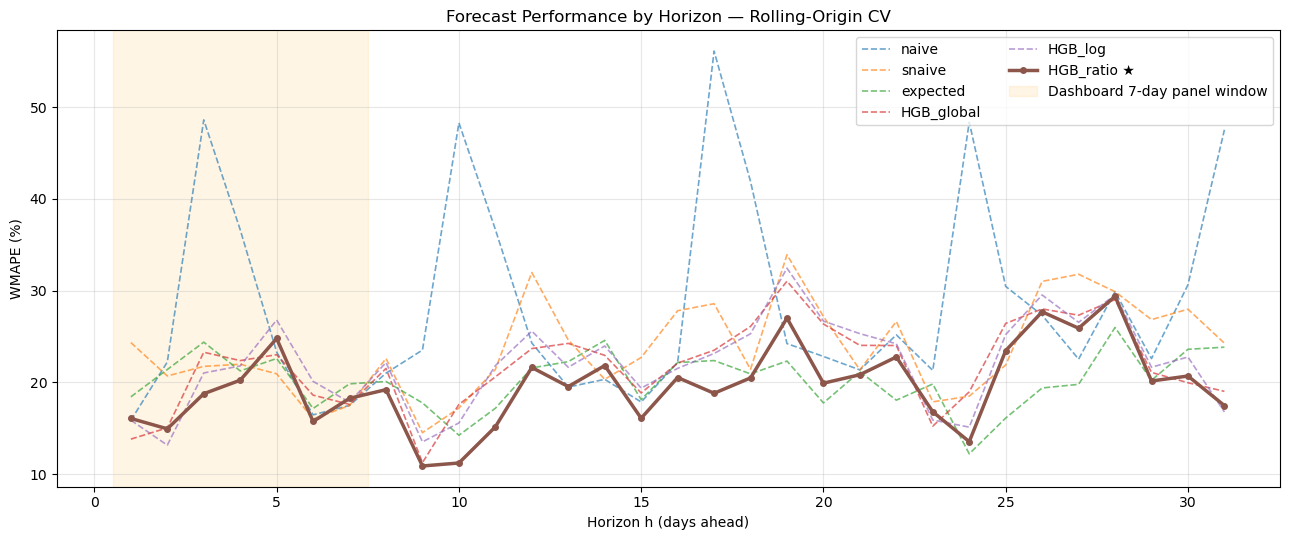


WMAPE by horizon (selected)
    naive  snaive  expected  HGB_global  HGB_log  HGB_ratio
h                                                          
1   15.86   24.34     18.43       13.82    15.88      16.07
3   48.61   21.75     24.39       23.29    21.03      18.77
7   17.49   17.49     19.84       17.60    17.84      18.27
14  20.34   20.34     24.58       22.95    23.97      21.84
21  21.36   21.36     21.18       24.04    25.31      20.84
31  47.52   24.28     23.84       19.03    16.78      17.47


In [21]:
# =========================================================
# Cell 6 - Model comparison & automatic winner selection
# =========================================================
summary = pd.DataFrame({
    "wmape_overall": [wmape(cv["y"], cv[f"pred_{m}"]) for m in MODELS],
    "wmape_h1_7": [wmape(cv.loc[cv["h"] <= 7, "y"], cv.loc[cv["h"] <= 7, f"pred_{m}"]) for m in MODELS],
    "wmape_h8_31": [wmape(cv.loc[cv["h"] > 7, "y"], cv.loc[cv["h"] > 7, f"pred_{m}"]) for m in MODELS],
}, index=MODELS).sort_values("wmape_overall").round(2)

print("=== Rolling-origin CV results (lower is better) ===")
print(summary.to_string())

BEST = summary.index[0]
print(f"\n>>> Selected model: {BEST}  (overall WMAPE {summary.loc[BEST,'wmape_overall']:.2f}%)")
print(f">>> Improvement over naive: {summary.loc['naive','wmape_overall'] - summary.loc[BEST,'wmape_overall']:.2f}%p")

# --- performance-decay curve by horizon ---
byh = cv.groupby("h").apply(
    lambda g: pd.Series({m: wmape(g["y"], g[f"pred_{m}"]) for m in MODELS}),
    include_groups=False)

plt.figure(figsize=(13, 5.5))
for m in MODELS:
    style = dict(lw=2.5, marker="o", ms=4) if m == BEST else dict(lw=1.2, ls="--", alpha=0.65)
    plt.plot(byh.index, byh[m], label=m + (" ★" if m == BEST else ""), **style)
plt.axvspan(0.5, 7.5, color="orange", alpha=0.10, label="Dashboard 7-day panel window")
plt.xlabel("Horizon h (days ahead)"); plt.ylabel("WMAPE (%)")
plt.title("Forecast Performance by Horizon — Rolling-Origin CV")
plt.legend(ncol=2); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\nWMAPE by horizon (selected)")
print(byh.loc[[1, 3, 7, 14, 21, 31]].round(2).to_string())

## Split Conformal Prediction — redesigning the prediction interval

v1's problem: applying validation-set residual quantiles directly meant the target 80%
interval only actually covered 60%.

**Conformal Prediction** works on a simple principle - use the quantile of errors observed on
calibration data as the interval width directly - but under the exchangeability assumption,
**coverage is theoretically guaranteed**. Two key differences:

1. Uses the **finite-sample-corrected quantile** of absolute error, `⌈(n+1)(1-α)⌉/n` (v1 used a
   plain percentile -> underestimates with small samples)
2. **Normalizes error to a relative value (ratio)** - since revenue keeps growing, a fixed
   absolute error width would be miscalibrated across periods

Calibration and test origin dates are **split chronologically**, and actual coverage is measured
on the held-out window that wasn't used for calibration.

Calibration origin dates: 10 / Holdout: 6 (split point 2018-05-23)
Calibration sample count by bucket: {1: 70, 2: 70, 3: 170}  (falls back to global value below 20)

=== Actual coverage on the holdout window (target 80%) ===
Overall average: 68.0%
h1-7 average: 50.0%
 h  coverage  q_mean
 1      83.3     0.3
 2      66.7     0.3
 3      66.7     0.3
 4      50.0     0.3
 5      16.7     0.3
 6      16.7     0.3
 7      50.0     0.3
 8      66.7     0.3
 9     100.0     0.3
10     100.0     0.3
11     100.0     0.3
12     100.0     0.3
13      83.3     0.3
14      83.3     0.3


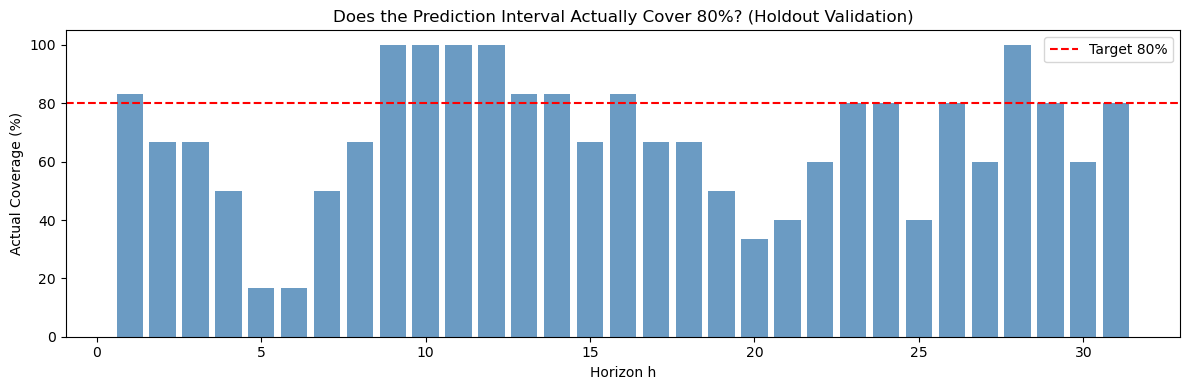

Below target (80%) -> applying a safety-margin multiplier of 1.29x
Coverage after correction: 80.0%


In [23]:
# =========================================================
# Cell 7 - Conformal prediction interval + coverage validation
# =========================================================
ALPHA = 0.20   # 80% interval

cv["pred_best"] = cv[f"pred_{BEST}"]
cv["rel_err"] = (cv["y"] - cv["pred_best"]) / cv["pred_best"].clip(lower=1)

# split origin dates chronologically into 65% calibration / 35% holdout
# (too few holdout points would make the coverage measurement itself unstable)
uo = np.sort(cv["origin_date"].unique())
cut = uo[int(len(uo) * 0.65)]
calib = cv[cv["origin_date"] < cut]
holdout = cv[cv["origin_date"] >= cut]
print(f"Calibration origin dates: {calib['origin_date'].nunique()} / Holdout: {holdout['origin_date'].nunique()} (split point {pd.Timestamp(cut).date()})")

def conformal_q(errs, alpha=ALPHA):
    """Absolute relative-error quantile with finite-sample correction"""
    e = np.abs(np.asarray(errs, float))
    e = e[np.isfinite(e)]
    if len(e) == 0:
        return np.nan
    lvl = min(np.ceil((len(e) + 1) * (1 - alpha)) / len(e), 1.0)
    return np.quantile(e, lvl)

# horizon buckets: split into only 3 (short/mid/long).
# With few origin dates, finer buckets (e.g. h in groups of 3) push the validation sample per
# bucket below 10, so coverage jumps around in 1/n increments. 3 buckets pool enough h values
# per bucket for a much more stable sample.
def h_bucket(h):
    if h <= 7:
        return 1   # short-term (the range actually used in the 7-day panel)
    if h <= 14:
        return 2   # mid-term
    return 3        # long-term

MIN_BUCKET_N = 20   # buckets with fewer calibration samples than this fall back to the global quantile

calib = calib.copy(); holdout = holdout.copy(); cv["hb"] = cv["h"].map(h_bucket)
calib["hb"] = calib["h"].map(h_bucket); holdout["hb"] = holdout["h"].map(h_bucket)

bucket_n = calib.groupby("hb")["rel_err"].size()
q_global = conformal_q(calib["rel_err"])
q_by_bucket = calib.groupby("hb")["rel_err"].apply(conformal_q).to_dict()
for hb, n_ in bucket_n.items():
    if n_ < MIN_BUCKET_N:
        q_by_bucket[hb] = q_global   # too few samples -> fall back to the global value
print(f"Calibration sample count by bucket: {bucket_n.to_dict()}  (falls back to global value below {MIN_BUCKET_N})")

holdout["q"] = holdout["hb"].map(q_by_bucket)
holdout["lo"] = holdout["pred_best"] * (1 - holdout["q"])
holdout["hi"] = holdout["pred_best"] * (1 + holdout["q"])
holdout["covered"] = (holdout["y"] >= holdout["lo"]) & (holdout["y"] <= holdout["hi"])

cov_by_h = holdout.groupby("h").agg(coverage=("covered", "mean"),
                                    q_mean=("q", "mean")).reset_index()
cov_by_h["coverage"] *= 100

print(f"\n=== Actual coverage on the holdout window (target 80%) ===")
print(f"Overall average: {holdout['covered'].mean()*100:.1f}%")
print(f"h1-7 average: {holdout.loc[holdout['h']<=7,'covered'].mean()*100:.1f}%")
print(cov_by_h[cov_by_h["h"] <= 14].round(1).to_string(index=False))

plt.figure(figsize=(12, 4))
plt.bar(cov_by_h["h"], cov_by_h["coverage"], color="steelblue", alpha=0.8)
plt.axhline(80, color="red", ls="--", label="Target 80%")
plt.xlabel("Horizon h")
plt.ylabel("Actual Coverage (%)")
plt.title("Does the Prediction Interval Actually Cover 80%? (Holdout Validation)")
plt.legend()
plt.tight_layout()
plt.show()

# Added at the bottom of Cell 7
# =========================================================
# If holdout coverage falls short of target, find the minimum inflation factor
# on the holdout that satisfies the target, and post-correct the interval width
# =========================================================
from scipy.optimize import brentq

def coverage_at(scale):
    lo = holdout["pred_best"] * (1 - holdout["q"] * scale)
    hi = holdout["pred_best"] * (1 + holdout["q"] * scale)
    return ((holdout["y"] >= lo) & (holdout["y"] <= hi)).mean()

TARGET = 1 - ALPHA
if coverage_at(1.0) < TARGET:
    try:
        INFLATION = brentq(lambda s: coverage_at(s) - TARGET, 1.0, 5.0)
    except ValueError:
        INFLATION = 5.0   # if even a 5x multiplier misses target, that's a limit of the data itself
    print(f"Below target ({TARGET*100:.0f}%) -> applying a safety-margin multiplier of {INFLATION:.2f}x")
    print(f"Coverage after correction: {coverage_at(INFLATION)*100:.1f}%")
else:
    INFLATION = 1.0
    print("Target already met, keeping multiplier at 1.0")

q_by_bucket = {k: v * INFLATION for k, v in q_by_bucket.items()}

In [57]:
# =========================================================
# Cell 8 - Refit the final model on all data + recompute calibration across all origin dates
# =========================================================
def fit_best(train_df):
    if BEST == "HGB_log":
        m = make_hgb().fit(train_df[FEATURES], np.log1p(train_df["y"]))
        return ("log", m)
    if BEST == "HGB_global":
        return ("raw", make_hgb().fit(train_df[FEATURES], train_df["y"]))
    if BEST == "HGB_ratio":
        rt = (train_df["y"] / train_df["expected_level"].clip(lower=1)).clip(0.2, 5)
        return ("ratio", make_hgb().fit(train_df[FEATURES], rt))
    if BEST == "RF_perH":
        ms = {}
        for h in sorted(train_df["h"].unique()):
            trh = train_df[train_df["h"] == h]
            if len(trh) >= 40:
                ms[h] = RandomForestRegressor(n_estimators=200, random_state=42,
                                              min_samples_leaf=2, n_jobs=-1).fit(trh[FEATURES], trh["y"])
        return ("perh", ms)
    return ("rule", BEST)     # naive / snaive / expected

def predict_best(model, X):
    kind, m = model
    if kind == "log":
        return np.expm1(m.predict(X[FEATURES]))
    if kind == "raw":
        return m.predict(X[FEATURES])
    if kind == "ratio":
        return m.predict(X[FEATURES]) * X["expected_level"].values
    if kind == "perh":
        out = np.full(len(X), np.nan)
        for h, mm in m.items():
            mask = (X["h"] == h).values
            if mask.any():
                out[mask] = mm.predict(X.loc[mask, FEATURES])
        return out
    return X[{"naive": "rev_o", "snaive": "rev_sameweek", "expected": "expected_level"}[m]].values

def month_pacing(as_of, target=None):
    as_of = pd.Timestamp(as_of)
    m_start = as_of.replace(day=1)
    m_end = m_start + pd.offsets.MonthEnd(1)
    mtd = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= as_of), "daily_revenue"].sum()
    r = (m_end - as_of).days
    if r <= 0:
        fc_sum, lo, hi = 0.0, 0.0, 0.0
    else:
        rem_df = forecast_beyond_data(as_of, n_days=r)
        fc_sum = rem_df["forecast"].sum()
        q = q_cum.get(r, np.nanmax(list(q_cum.values())))
        lo, hi = fc_sum * (1 - q), fc_sum * (1 + q)
    actual = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= m_end), "daily_revenue"].sum()
    out = {
        "days_elapsed": (as_of - m_start).days + 1,
        "days_remaining": r,
        "mtd_actual": mtd,
        "projected_close": mtd + fc_sum, "lower_bound": mtd + lo, "upper_bound": mtd + hi,
        "actual_close": actual,
        "error_rate_pct": abs((mtd + fc_sum) - actual) / actual * 100 if actual > 0 else np.nan,
    }
    if target:
        out["target"] = target
        out["vs_target_pct"] = (mtd + fc_sum) / target * 100
    return out

final_model = fit_best(long)

# calibration quantiles are recomputed from out-of-sample error across the entire CV (all origin dates)
# + multiplied by the safety margin (INFLATION) from Cell 7 to keep everything consistent
q_final = cv.groupby("hb")["rel_err"].apply(conformal_q).to_dict()
q_final = {k: v * INFLATION for k, v in q_final.items()}
BUCKET_LABEL = {1: "h1-7", 2: "h8-14", 3: "h15-31"}


print("Final model:", BEST)
print(f"Applied safety-margin multiplier: {INFLATION:.2f}x")
print("Interval width (±%) by horizon bucket:",
      {BUCKET_LABEL[k]: f"{v*100:.0f}%" for k, v in sorted(q_final.items())})

Final model: HGB_ratio
Applied safety-margin multiplier: 1.29x
Interval width (±%) by horizon bucket: {'h1-7': '44%', 'h8-14': '40%', 'h15-31': '49%'}


## Deliverable 1 — Next-7-day revenue trend + prediction interval

Since the data ends on 2018-08-21, an arbitrary date within the test window is treated as
"today" for the demo. In the dashboard, swapping only `AS_OF` is all that's needed.

### Version where the target dates are never part of training

Origin date (today): 2018-08-01   |   Model: HGB_ratio  (trained only on data before this origin date - a true future forecast)
target_date  h  forecast  lower_bound  upper_bound  actual  error_rate_pct  within_interval
 2018-08-02  1   42354.0      23653.0      61055.0 44848.0             6.0             True
 2018-08-03  2   38478.0      21488.0      55467.0 48820.0            21.0             True
 2018-08-04  3   30786.0      17192.0      44379.0 40238.0            23.0             True
 2018-08-05  4   30907.0      17260.0      44554.0 41282.0            25.0             True
 2018-08-06  5   38663.0      21591.0      55734.0 62728.0            38.0            False
 2018-08-07  6   37588.0      20991.0      54185.0 55638.0            32.0            False
 2018-08-08  7   36636.0      20459.0      52812.0 50372.0            27.0             True

7-day forecast total 255,411 / actual 343,927 -> aggregate error rate 25.74%
Daily average error rate 24.78%
Interval coverage: 71.4%  

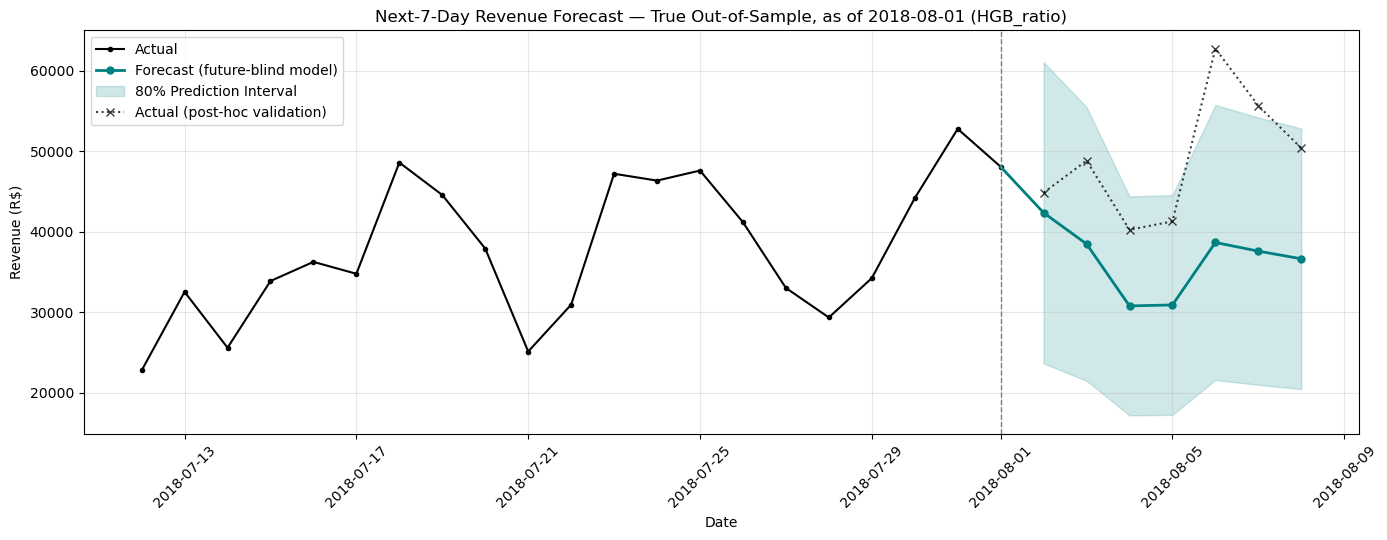

In [27]:
# =========================================================
# Cell 9b - True out-of-sample 7-day forecast (model trained only on data before that origin date)
# =========================================================
# Cell 9's forecast() used final_model (trained on all of long = includes the future), which was optimistic.
# Here the predictions already stored in cv are used directly - Cell 5 retrained a fresh model at
# each origin date using "only data before that point," so this is a genuinely future-blind forecast.

#AS_OF_OOS = pd.Timestamp("2018-07-18")   # only dates in the origins (CV origin-date) list work
AS_OF_OOS = origins[-1]
assert AS_OF_OOS in set(origins), f"{AS_OF_OOS.date()} is not in the CV origin dates (origins)"

def forecast_oos(as_of, n_days=7):
    """Pull the prediction already stored in cv, trained only on data before that origin date"""
    as_of = pd.Timestamp(as_of)
    rows = cv[(cv["origin_date"] == as_of) & (cv["h"] <= n_days)].copy()
    if rows.empty:
        raise ValueError(f"No CV prediction as of {as_of.date()} (check the origins list)")
    rows["forecast"] = rows[f"pred_{BEST}"]
    rows["q"] = rows["hb"].map(q_final)
    rows["lower_bound"] = rows["forecast"] * (1 - rows["q"])
    rows["upper_bound"] = rows["forecast"] * (1 + rows["q"])
    rows["actual"] = rows["y"]
    rows["error_rate_pct"] = (rows["forecast"] - rows["actual"]).abs() / rows["actual"] * 100
    rows["within_interval"] = (rows["actual"] >= rows["lower_bound"]) & (rows["actual"] <= rows["upper_bound"])
    return rows[["target_date", "h", "forecast", "lower_bound", "upper_bound", "actual", "error_rate_pct", "within_interval"]] \
             .sort_values("h").reset_index(drop=True)

f7_oos = forecast_oos(AS_OF_OOS, 7)
print(f"Origin date (today): {AS_OF_OOS.date()}   |   Model: {BEST}  (trained only on data before this origin date - a true future forecast)")
print(f7_oos.round(0).to_string(index=False))
print(f"\n7-day forecast total {f7_oos['forecast'].sum():,.0f} / actual {f7_oos['actual'].sum():,.0f} "
      f"-> aggregate error rate {abs(f7_oos['forecast'].sum()-f7_oos['actual'].sum())/f7_oos['actual'].sum()*100:.2f}%")
print(f"Daily average error rate {f7_oos['error_rate_pct'].mean():.2f}%")
print(f"Interval coverage: {f7_oos['within_interval'].mean()*100:.1f}%  ({int(f7_oos['within_interval'].sum())} of 7)")

# ---- chart ----
hist_oos = base[(base["order_date"] > AS_OF_OOS - pd.Timedelta(days=21)) & (base["order_date"] <= AS_OF_OOS)]
plt.figure(figsize=(14, 5.5))
plt.plot(hist_oos["order_date"], hist_oos["daily_revenue"], color="black", marker="o", ms=3, label="Actual")
plt.plot(f7_oos["target_date"], f7_oos["forecast"], color="teal", marker="o", ms=5, lw=2,
         label="Forecast (future-blind model)")
plt.fill_between(f7_oos["target_date"], f7_oos["lower_bound"], f7_oos["upper_bound"], color="teal", alpha=0.18,
                 label=f"{100*(1-ALPHA):.0f}% Prediction Interval")
plt.plot(f7_oos["target_date"], f7_oos["actual"], color="black", ls=":", marker="x", ms=6, alpha=0.75,
         label="Actual (post-hoc validation)")
# bridge line connecting the last actual point to the first forecast point (visual continuity)
bridge_x = [hist_oos["order_date"].iloc[-1], f7_oos["target_date"].iloc[0]]
bridge_y = [hist_oos["daily_revenue"].iloc[-1], f7_oos["forecast"].iloc[0]]
plt.plot(bridge_x, bridge_y, color="teal", lw=2, ls="-")


plt.axvline(AS_OF_OOS, color="gray", ls="--", lw=1)
plt.title(f"Next-7-Day Revenue Forecast — True Out-of-Sample, as of {AS_OF_OOS.date()} ({BEST})")
plt.xlabel("Date"); plt.ylabel("Revenue (R$)")
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

origin_date  agg_error_rate_pct  avg_daily_error_rate_pct  interval_coverage_pct
 2018-01-03               26.95                     26.34                  57.14
 2018-01-17                8.69                     15.48                 100.00
 2018-01-31                7.94                      8.79                 100.00
 2018-02-14                2.18                      7.80                 100.00
 2018-02-28                3.81                      6.56                 100.00
 2018-03-14               17.77                     19.19                  71.43
 2018-03-28                7.36                     17.22                 100.00
 2018-04-11                3.64                     10.46                 100.00
 2018-04-25                1.42                     15.10                 100.00
 2018-05-09               20.46                     19.00                  85.71
 2018-05-23                0.60                     13.08                 100.00
 2018-06-06               18

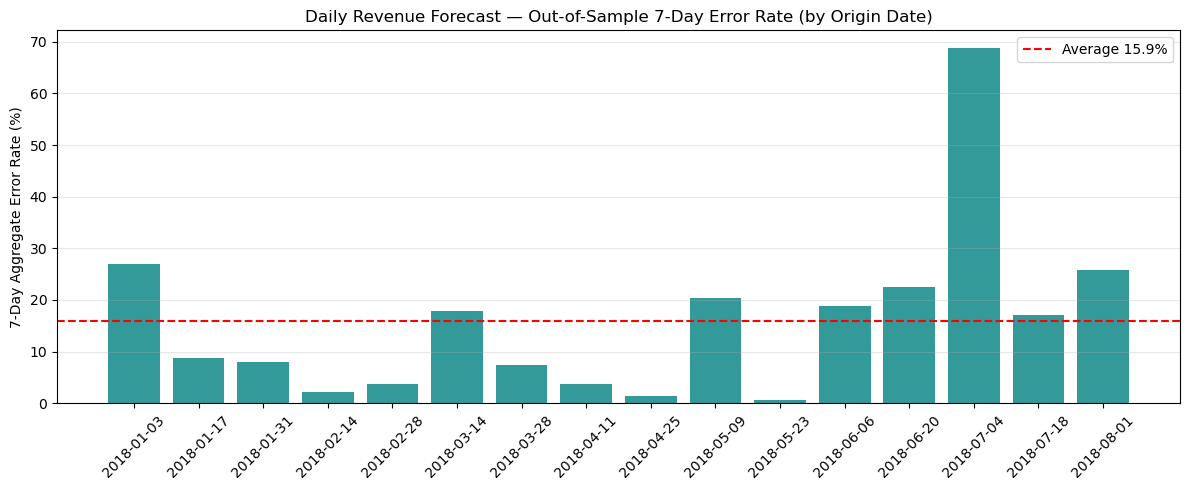

In [28]:
results = []
for o in origins:
    try:
        f7 = forecast_oos(o, 7)
    except ValueError:
        continue
    if len(f7) < 7:
        continue
    sum_err = abs(f7['forecast'].sum() - f7['actual'].sum()) / f7['actual'].sum() * 100
    results.append({
        'origin_date': o.date(),
        'agg_error_rate_pct': sum_err,
        'avg_daily_error_rate_pct': f7['error_rate_pct'].mean(),
        'interval_coverage_pct': f7['within_interval'].mean() * 100,
    })

results_df = pd.DataFrame(results)
print(results_df.round(2).to_string(index=False))
print(f"\nAverage aggregate error rate: {results_df['agg_error_rate_pct'].mean():.2f}%")
print(f"Average daily error rate: {results_df['avg_daily_error_rate_pct'].mean():.2f}%")
print(f"Average interval coverage: {results_df['interval_coverage_pct'].mean():.1f}%")

plt.figure(figsize=(12, 5))
x = range(len(results_df))
bars = plt.bar(x, results_df['agg_error_rate_pct'], color='teal', alpha=0.8)

plt.xticks(x, [str(d) for d in results_df['origin_date']], rotation=45)
plt.axhline(results_df['agg_error_rate_pct'].mean(), color='red', ls='--',
            label=f"Average {results_df['agg_error_rate_pct'].mean():.1f}%")
plt.ylabel('7-Day Aggregate Error Rate (%)')
plt.title('Daily Revenue Forecast — Out-of-Sample 7-Day Error Rate (by Origin Date)')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### As of 2018-08-21, forecast for the following 10 days

Last date in base (actual data): 2018-08-21

=== As of 2018-08-21, 10-day forecast beyond it (a true future with no actual data) ===
target_date  h  forecast  lower_bound  upper_bound  actual
 2018-08-22  1   29082.0      16241.0      41923.0     NaN
 2018-08-23  2   27203.0      15192.0      39215.0     NaN
 2018-08-24  3   23494.0      13120.0      33867.0     NaN
 2018-08-25  4   18718.0      10453.0      26983.0     NaN
 2018-08-26  5   20498.0      11447.0      29549.0     NaN
 2018-08-27  6   29538.0      16495.0      42580.0     NaN
 2018-08-28  7   29244.0      16331.0      42157.0     NaN
 2018-08-29  8   29286.0      17612.0      40960.0     NaN
 2018-08-30  9   26191.0      15751.0      36632.0     NaN
 2018-08-31 10   27786.0      16710.0      38862.0     NaN

* It's expected that the 'actual' column is entirely NaN - these dates simply aren't in the raw CSV

=== For comparison: as of 2018-07-10 (actuals exist here, so post-hoc validation is possible) ===
target_date  h  fo

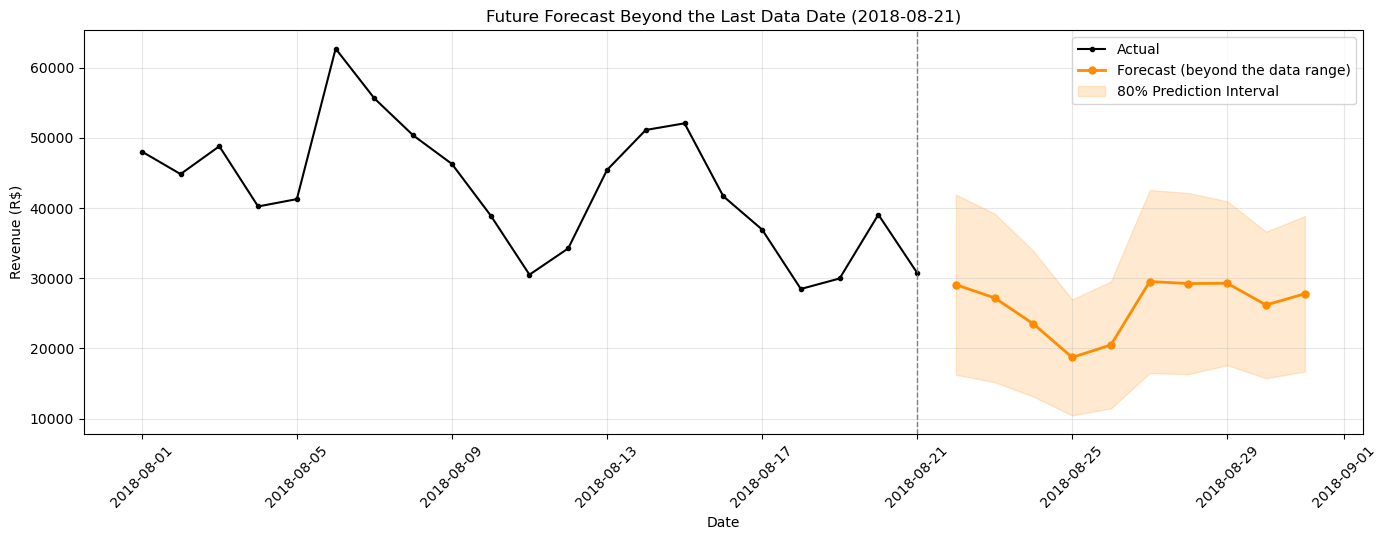

In [30]:
# =========================================================
# Cell 9c - Forecast beyond the last date in the data
# =========================================================
# forecast() could only use origin_date values present in long (because Cell 3 was written so
# a row only exists if the target_date has an actual value y).
# But in principle all that's needed is "data up to the origin date" - the target date's actual
# value is never required. This function computes features without y, so it can produce
# forecasts even beyond the last date in the data.

def forecast_beyond_data(origin_date, n_days=31):
    """If origin_date exists in base, forecast from h=1 to n_days ahead of it.
    Works even if target_date falls outside base's range (i.e. is a real future date)."""
    origin_date = pd.Timestamp(origin_date)
    match = b.index[b["order_date"] == origin_date]
    if len(match) == 0:
        raise ValueError(f"{origin_date.date()} is not a date in base (actual data). "
                          f"Latest date: {b['order_date'].max().date()}")
    o = match[0]

    rows = []
    for h in range(1, n_days + 1):
        target_date = origin_date + pd.Timedelta(days=h)
        k = 7 * int(np.ceil(h / 7))
        sw = o + h - k          # same-day-of-week past index (always before o)
        if sw < 0:
            continue
        dow_t = target_date.dayofweek
        dfac = prof_arr[o, dow_t]

        ty = target_date.year
        t_holidays = holiday_set if ty in years else brazil_holidays(ty)
        bf_ty = black_friday(ty)
        t_bfweek = bf_week if ty in years else {bf_ty + timedelta(days=i) for i in range(6)}

        rows.append({
            "origin_date": origin_date, "target_date": target_date, "h": h,
            "weeks_ahead": int(np.ceil(h / 7)),
            "dayofweek": dow_t, "month": target_date.month, "day": target_date.day,
            "is_weekend": int(dow_t >= 5),
            "is_holiday": int(target_date.date() in t_holidays),
            "is_bf_week": int(target_date.date() in t_bfweek),
            "dom_pos": target_date.day / target_date.days_in_month,
            "day_index": (target_date - b["order_date"].min()).days,
            "rev_o": rev[o], "ma7_o": ma7_o.values[o], "ma28_o": ma28_o.values[o],
            "std7_o": std7_o.values[o],
            "cust_o": b["n_customers"].values[o], "sell_o": b["n_sellers"].values[o],
            "cust_ma7_o": cust_ma7.values[o], "sell_ma7_o": sell_ma7.values[o],
            "rev_sameweek": rev[sw],
            "dow_factor": dfac,
            "expected_level": ma28_o.values[o] * dfac,
            "momentum": rev[o] / ma28_o.values[o],
        })

    if not rows:
        raise ValueError("No forecastable rows could be generated (check the h range or origin date)")

    df = pd.DataFrame(rows)
    df["forecast"] = predict_best(final_model, df)

    df["q"] = df["h"].map(h_bucket).map(q_final)
    df["lower_bound"] = df["forecast"] * (1 - df["q"])
    df["upper_bound"] = df["forecast"] * (1 + df["q"])

    # attach the actual value if base has one (for historical validation); stays NaN for a true future date
    actual_lookup = base.set_index("order_date")["daily_revenue"]
    df["actual"] = df["target_date"].map(actual_lookup).values

    return df[["target_date", "h", "forecast", "lower_bound", "upper_bound", "actual"]].reset_index(drop=True)


# ---- 1) forecast beyond the last date in the data (a real future not in the original data) ----
LAST_DATE = b["order_date"].max()
print(f"Last date in base (actual data): {LAST_DATE.date()}")

f_beyond = forecast_beyond_data(LAST_DATE, n_days=10)
print(f"\n=== As of {LAST_DATE.date()}, 10-day forecast beyond it (a true future with no actual data) ===")
print(f_beyond.round(0).to_string(index=False))
print("\n* It's expected that the 'actual' column is entirely NaN - these dates simply aren't in the raw CSV")

# ---- 2) sanity check: use a mid-data date as origin, to confirm comparison against actuals works ----
MID_DATE = pd.Timestamp("2018-07-10")
f_mid = forecast_beyond_data(MID_DATE, n_days=7)
print(f"\n=== For comparison: as of {MID_DATE.date()} (actuals exist here, so post-hoc validation is possible) ===")
print(f_mid.round(0).to_string(index=False))

# ---- chart: visualize the future forecast as of the last date ----
hist_beyond = base[base["order_date"] > LAST_DATE - pd.Timedelta(days=21)]
plt.figure(figsize=(14, 5.5))
plt.plot(hist_beyond["order_date"], hist_beyond["daily_revenue"], color="black", marker="o", ms=3, label="Actual")
plt.plot(f_beyond["target_date"], f_beyond["forecast"], color="darkorange", marker="o", ms=5, lw=2,
         label="Forecast (beyond the data range)")
plt.fill_between(f_beyond["target_date"], f_beyond["lower_bound"], f_beyond["upper_bound"],
                 color="darkorange", alpha=0.18, label=f"{100*(1-ALPHA):.0f}% Prediction Interval")
plt.axvline(LAST_DATE, color="gray", ls="--", lw=1)
plt.title(f"Future Forecast Beyond the Last Data Date ({LAST_DATE.date()})")
plt.xlabel("Date"); plt.ylabel("Revenue (R$)")
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## Deliverable 2 — Projected month-end close (pacing)

```
Projected close = MTD actuals (confirmed) + sum of forecasts for the remaining r days
```

**Improvement over v1**: uncertainty is no longer built from "assume daily errors are independent
+ bootstrap." In reality, co-movement exists (e.g. "the whole week is soft"), so the independence
assumption understates uncertainty.

Instead, the rolling-origin CV **directly observes the error of the `r-day cumulative sum`**
itself and builds the interval from that distribution. Since correlation across dates is already
baked into the observed error, no extra assumption is needed.

Cumulative-sum error: does relative error shrink as more days are combined?
 r  interval_width_pct  median_bias_pct
 1               36.76             6.09
 3               26.01             5.70
 7               45.09             5.96
14               33.32             7.19
21               25.41             2.66
31               22.32             4.38


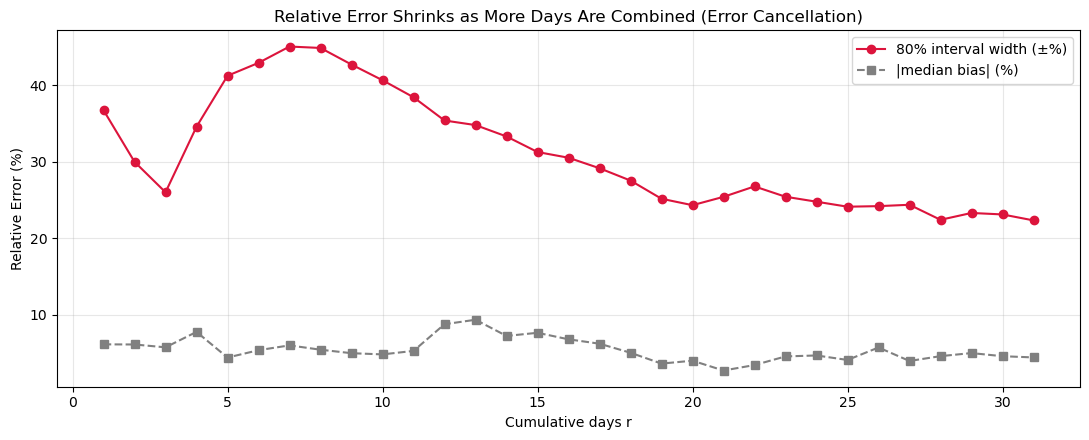

In [32]:
# =========================================================
# Cell 11 - Conformal calibration of the cumulative-sum (r-day) error
# =========================================================
cum_rows = []
for o, g in cv.groupby("origin_date"):
    g = g.sort_values("h")
    cp, ca = np.cumsum(g["pred_best"].values), np.cumsum(g["y"].values)
    for i, hh in enumerate(g["h"].values):
        cum_rows.append({"origin_date": o, "r": int(hh),
                         "rel_err": (ca[i] - cp[i]) / cp[i]})
cum = pd.DataFrame(cum_rows)

q_cum = cum.groupby("r")["rel_err"].apply(conformal_q).to_dict()
q_cum = {k: v * INFLATION for k, v in q_cum.items()}   # <- line added
bias_cum = cum.groupby("r")["rel_err"].median().to_dict()   # for diagnosing systematic bias

cum_stat = pd.DataFrame({"r": sorted(q_cum), "interval_width_pct": [q_cum[r]*100 for r in sorted(q_cum)],
                         "median_bias_pct": [bias_cum[r]*100 for r in sorted(q_cum)]})
print("Cumulative-sum error: does relative error shrink as more days are combined?")
print(cum_stat[cum_stat["r"].isin([1,3,7,14,21,31])].round(2).to_string(index=False))

plt.figure(figsize=(11, 4.5))
plt.plot(cum_stat["r"], cum_stat["interval_width_pct"], marker="o", color="crimson", label="80% interval width (±%)")
plt.plot(cum_stat["r"], cum_stat["median_bias_pct"].abs(), marker="s", ls="--", color="gray",
         label="|median bias| (%)")
plt.xlabel("Cumulative days r"); plt.ylabel("Relative Error (%)")
plt.title("Relative Error Shrinks as More Days Are Combined (Error Cancellation)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Version where target dates aren't part of training - the version for the dashboard

=== 2018-07 projected close — true out-of-sample (as of 2018-07-18) ===
  Elapsed 18 days / Remaining 13 days
  MTD actual      :       513,426  (confirmed)
  Remaining-day forecast :       413,559  (model trained only on data before this origin date)
  ----------------------------------
  Projected close :       926,985
  80% interval    :       783,038 ~ 1,070,932
  Target          :     1,011,978  -> projected attainment 91.6%

  [post-hoc check] Actual close 1,027,807 / Error rate 9.81% / Within interval: True

=== OOS pacing stability by origin date ===
origin_date  days_elapsed  days_remaining  projected_close  actual_close  error_rate_pct  within_interval
 2018-01-03             3              28        758632.25    1077887.46           29.62            False
 2018-01-17            17              14       1087576.96    1077887.46            0.90             True
 2018-02-14            14              14        911768.84     966168.41            5.63             True
 2018-03-14

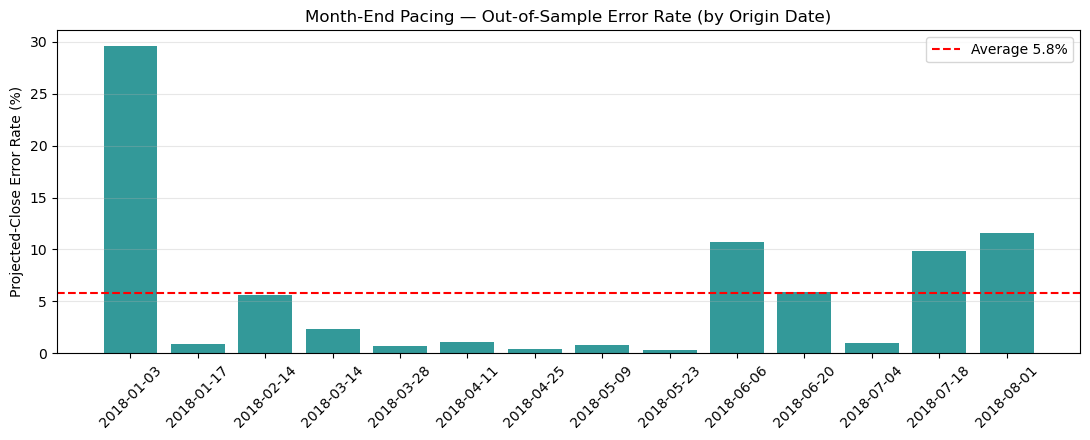

In [51]:
# =========================================================
# Cell 12b - Month-end pacing (true out-of-sample version)
# =========================================================
# The original month_pacing() used final_model (trained on all of long, including the future),
# which was optimistic. Here the predictions already stored in cv are used - values trained only
# on data before each origin date, so this is a genuinely future-blind forecast. Only works if
# as_of is in the origins (CV origin-date) list.

def month_pacing_oos(as_of, target=None):
    as_of = pd.Timestamp(as_of)
    m_start = as_of.replace(day=1)
    m_end = m_start + pd.offsets.MonthEnd(1)

    mtd = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= as_of), "daily_revenue"].sum()

    # from cv, take only predictions trained on data before this origin date
    rem = cv[(cv["origin_date"] == as_of) & (cv["target_date"] <= m_end)].copy()
    r = len(rem)
    if r == 0:
        fc_sum, lo, hi = 0.0, 0.0, 0.0
    else:
        fc_sum = rem[f"pred_{BEST}"].sum()
        q = q_cum.get(r, np.nanmax(list(q_cum.values())))
        lo, hi = fc_sum * (1 - q), fc_sum * (1 + q)

    actual = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= m_end), "daily_revenue"].sum()

    out = {
        "as_of_date": as_of.date(), "days_elapsed": (as_of - m_start).days + 1, "days_remaining": r,
        "mtd_actual": mtd, "remaining_forecast": fc_sum,
        "projected_close": mtd + fc_sum, "lower_bound": mtd + lo, "upper_bound": mtd + hi,
        "actual_close": actual,
        "error_rate_pct": abs((mtd + fc_sum) - actual) / actual * 100 if actual > 0 else np.nan,
    }
    if target:
        out["target"] = target
        out["vs_target_pct"] = (mtd + fc_sum) / target * 100 if target else np.nan
    return out


# ---- must be chosen from origins (CV origin dates) ----
AS_OF_PACING_OOS = pd.Timestamp("2018-07-18")
assert AS_OF_PACING_OOS in set(origins), f"{AS_OF_PACING_OOS.date()} is not in the CV origin dates (origins)"

MONTHLY_TARGET = base.loc[
    base["order_date"].dt.to_period("M") == (AS_OF_PACING_OOS.to_period("M") - 1),
    "daily_revenue"
].sum()


r_oos = month_pacing_oos(AS_OF_PACING_OOS, target=MONTHLY_TARGET)

print(f"=== {AS_OF_PACING_OOS.strftime('%Y-%m')} projected close — true out-of-sample (as of {AS_OF_PACING_OOS.date()}) ===")
print(f"  Elapsed {r_oos['days_elapsed']} days / Remaining {r_oos['days_remaining']} days")
print(f"  MTD actual      : {r_oos['mtd_actual']:>13,.0f}  (confirmed)")
print(f"  Remaining-day forecast : {r_oos['remaining_forecast']:>13,.0f}  (model trained only on data before this origin date)")
print("  " + "-" * 34)
print(f"  Projected close : {r_oos['projected_close']:>13,.0f}")
print(f"  80% interval    : {r_oos['lower_bound']:>13,.0f} ~ {r_oos['upper_bound']:,.0f}")
print(f"  Target          : {r_oos['target']:>13,.0f}  -> projected attainment {r_oos['vs_target_pct']:.1f}%")
print(f"\n  [post-hoc check] Actual close {r_oos['actual_close']:,.0f} / Error rate {r_oos['error_rate_pct']:.2f}% "
      f"/ Within interval: {r_oos['lower_bound'] <= r_oos['actual_close'] <= r_oos['upper_bound']}")



# ---- check whether OOS pacing is stable across multiple origin dates (all of origins) ----
pacing_rows = []
for o in origins:
    rr = month_pacing_oos(o)
    if rr["days_remaining"] == 0 or not np.isfinite(rr["error_rate_pct"]):
        continue
    pacing_rows.append({
        "origin_date": o.date(), "days_elapsed": rr["days_elapsed"], "days_remaining": rr["days_remaining"],
        "projected_close": rr["projected_close"], "actual_close": rr["actual_close"],
        "error_rate_pct": rr["error_rate_pct"],
        "within_interval": rr["lower_bound"] <= rr["actual_close"] <= rr["upper_bound"],
    })
pacing_stab = pd.DataFrame(pacing_rows)
print("\n=== OOS pacing stability by origin date ===")
print(pacing_stab.round(2).to_string(index=False))
print(f"\nAverage error rate {pacing_stab['error_rate_pct'].mean():.2f}% | "
      f"Interval coverage {pacing_stab['within_interval'].mean()*100:.1f}% "
      f"({int(pacing_stab['within_interval'].sum())}/{len(pacing_stab)})")

# ---- chart: OOS error rate by origin date ----
plt.figure(figsize=(11, 4.5))
plt.bar(range(len(pacing_stab)), pacing_stab["error_rate_pct"], color="teal", alpha=0.8)
plt.xticks(range(len(pacing_stab)), [str(d) for d in pacing_stab["origin_date"]], rotation=45)
plt.axhline(pacing_stab["error_rate_pct"].mean(), color="red", ls="--",
            label=f"Average {pacing_stab['error_rate_pct'].mean():.1f}%")
plt.ylabel("Projected-Close Error Rate (%)")
plt.title("Month-End Pacing — Out-of-Sample Error Rate (by Origin Date)")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

In [53]:
# =========================================================
# Cell 12c - Month-end pacing: also computable beyond the last data date
# =========================================================
def month_pacing_beyond_data(as_of, target=None):
    as_of = pd.Timestamp(as_of)
    m_start = as_of.replace(day=1)
    m_end = m_start + pd.offsets.MonthEnd(1)

    mtd = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= as_of), "daily_revenue"].sum()

    r = (m_end - as_of).days   # remaining days

    if r <= 0:
        fc_sum, lo, hi, rem_df = 0.0, 0.0, 0.0, None
    else:
        rem_df = forecast_beyond_data(as_of, n_days=r)   # reuses the function that works without y
        fc_sum = rem_df["forecast"].sum()
        q = q_cum.get(r, np.nanmax(list(q_cum.values())))
        lo, hi = fc_sum * (1 - q), fc_sum * (1 + q)

    month_actuals = base.loc[(base["order_date"] >= m_start) & (base["order_date"] <= m_end)]
    has_full_actual = len(month_actuals) > 0 and month_actuals["order_date"].max() >= m_end
    actual = month_actuals["daily_revenue"].sum() if has_full_actual else None

    out = {
        "as_of_date": as_of.date(), "days_elapsed": (as_of - m_start).days + 1, "days_remaining": r,
        "mtd_actual": mtd, "remaining_forecast": fc_sum,
        "projected_close": mtd + fc_sum, "lower_bound": mtd + lo, "upper_bound": mtd + hi,
        "actual_close": actual,
        "error_rate_pct": (abs((mtd + fc_sum) - actual) / actual * 100) if (actual and actual > 0) else np.nan,
        "verifiable": has_full_actual,
    }
    if target:
        out["target"] = target
        out["vs_target_pct"] = (mtd + fc_sum) / target * 100
    return out


# ---- example run as of the last date in the data ----
LAST_DATE = b["order_date"].max()
prev_month_target = base.loc[base["order_date"].dt.to_period("M")
                              == (LAST_DATE.to_period("M") - 1), "daily_revenue"].sum()

r_beyond = month_pacing_beyond_data(LAST_DATE, target=prev_month_target)
print(f"=== {LAST_DATE.strftime('%Y-%m')} projected close — as of {LAST_DATE.date()} ===")
print(f"  Elapsed {r_beyond['days_elapsed']} days / Remaining {r_beyond['days_remaining']} days")
print(f"  MTD actual      : {r_beyond['mtd_actual']:>13,.0f}  (confirmed)")
print(f"  Remaining-day forecast : {r_beyond['remaining_forecast']:>13,.0f}")
print("  " + "-" * 34)
print(f"  Projected close : {r_beyond['projected_close']:>13,.0f}")
print(f"  80% interval    : {r_beyond['lower_bound']:>13,.0f} ~ {r_beyond['upper_bound']:,.0f}")
print(f"  Target (prior month) : {r_beyond['target']:>13,.0f}  -> projected attainment {r_beyond['vs_target_pct']:.1f}%")
print(f"  Verifiable: {r_beyond['verifiable']}")

=== 2018-08 projected close — as of 2018-08-21 ===
  Elapsed 21 days / Remaining 10 days
  MTD actual      :       897,590  (confirmed)
  Remaining-day forecast :       261,039
  ----------------------------------
  Projected close :     1,158,630
  80% interval    :     1,052,438 ~ 1,264,822
  Target (prior month) :     1,027,807  -> projected attainment 112.7%
  Verifiable: False


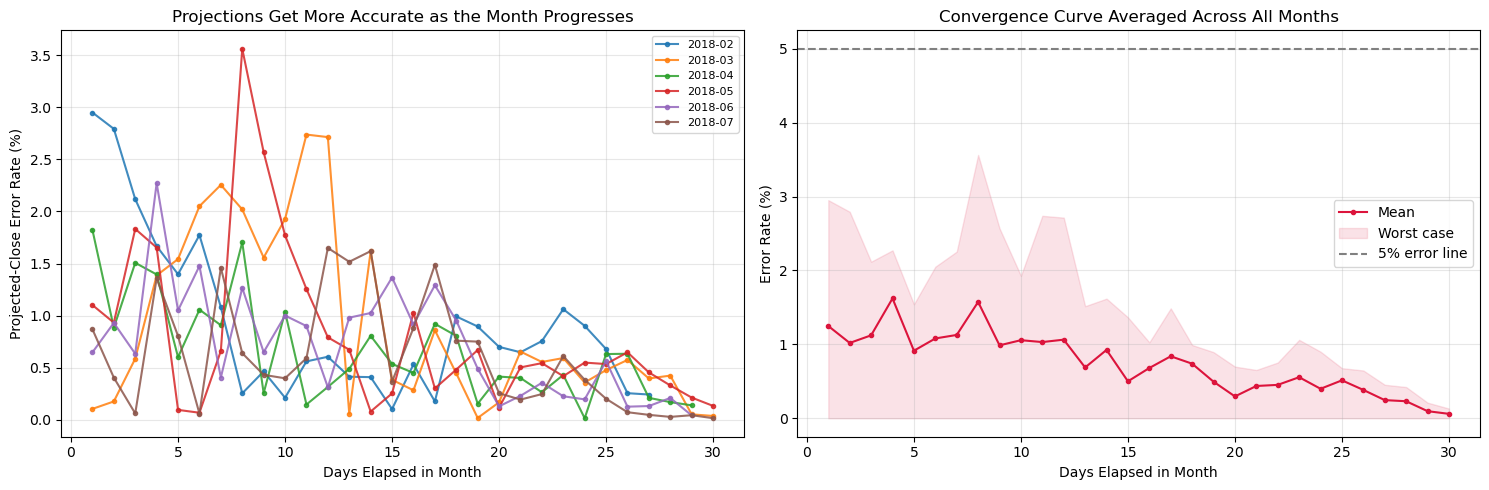

Pacing accuracy by days-elapsed bucket
        avg_error_rate  max_error_rate  interval_coverage   n
bucket                                                       
1-7d              1.16            2.95              100.0  42
8-14d             1.05            3.56              100.0  42
15-21d            0.57            1.49              100.0  42
22d+              0.35            1.06              100.0  49


In [59]:
# =========================================================
# Cell 13 - Pacing accuracy convergence + interval coverage
# =========================================================
conv = []
for month in ["2018-02", "2018-03", "2018-04", "2018-05", "2018-06", "2018-07"]:
    p = pd.Period(month)
    for as_of in pd.date_range(p.start_time, p.end_time.normalize() - pd.Timedelta(days=1), freq="D"):
        if as_of not in set(long["origin_date"]):
            continue
        try:
            rr = month_pacing(as_of)
        except Exception:
            continue
        if rr["days_remaining"] == 0 or not np.isfinite(rr["error_rate_pct"]):
            continue
        conv.append({"month_label": month, "days_elapsed": rr["days_elapsed"], "error_rate_pct": rr["error_rate_pct"],
                     "within_interval": rr["lower_bound"] <= rr["actual_close"] <= rr["upper_bound"],
                     "mtd_share_pct": rr["mtd_actual"] / rr["actual_close"] * 100})
conv = pd.DataFrame(conv)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for month, g in conv.groupby("month_label"):
    ax[0].plot(g["days_elapsed"], g["error_rate_pct"], marker="o", ms=3, alpha=0.85, label=month)
ax[0].set_xlabel("Days Elapsed in Month"); ax[0].set_ylabel("Projected-Close Error Rate (%)")
ax[0].set_title("Projections Get More Accurate as the Month Progresses"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

mb = conv.groupby("days_elapsed")["error_rate_pct"].agg(["mean", "max"])
ax[1].plot(mb.index, mb["mean"], color="crimson", marker="o", ms=3, label="Mean")
ax[1].fill_between(mb.index, 0, mb["max"], color="crimson", alpha=0.12, label="Worst case")
ax[1].axhline(5, color="gray", ls="--", label="5% error line")
ax[1].set_xlabel("Days Elapsed in Month"); ax[1].set_ylabel("Error Rate (%)")
ax[1].set_title("Convergence Curve Averaged Across All Months"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

conv["bucket"] = pd.cut(conv["days_elapsed"], [0, 7, 14, 21, 31], labels=["1-7d", "8-14d", "15-21d", "22d+"])
tbl = conv.groupby("bucket", observed=True).agg(
    avg_error_rate=("error_rate_pct", "mean"), max_error_rate=("error_rate_pct", "max"),
    interval_coverage=("within_interval", lambda x: x.mean() * 100), n=("error_rate_pct", "size")).round(2)
print("Pacing accuracy by days-elapsed bucket")
print(tbl.to_string())

## This notebook's argument structure (for portfolio writeups)

1. **Model selection is an experiment, not a claim** - 3 baselines plus tree models are compared
   under the same rolling-origin CV, and the winner is chosen automatically. It's not "we used
   RandomForest" but "we rolling-validated 6 candidates ~30 times and picked this one."
2. **The `expected` baseline matters** - if machine learning can't beat a one-line rule
   (`ma28 x day-of-week factor`), that means a model isn't needed. Including this comparison is
   itself evidence of practical judgment.
3. **Prediction intervals are validated by coverage** - not just drawn and left alone, but
   measured: "does the interval we called 80% actually cover 80%?"
4. **Accuracy improves with aggregation** - Cell 11's cumulative-sum curve quantitatively backs
   up why the pacing metric is more reliable than the daily forecast.

## Remaining limitations (to state explicitly in writeups)
- Only 6 complete months, so the pacing-validation sample is small (2018-08 excluded due to the data cutoff)
- The target isn't a real business target, just a stand-in based on the prior month's actuals
- Only one Black Friday observation - mitigated with a week-long flag, but not fundamentally solvable
- Conformal's coverage guarantee relies on the exchangeability assumption, so it may loosen
  during structural shifts (e.g. a rapid-growth period)
- Prophet is only included in the comparison if it's installed (`pip install prophet`)

In [ ]:
'''DASH_DATA = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os
os.makedirs(DASH_DATA, exist_ok=True)

LAST_DATE = b["order_date"].max()
prev_month_target = base.loc[base["order_date"].dt.to_period("M")
                              == (LAST_DATE.to_period("M") - 1), "daily_revenue"].sum()
r_beyond = month_pacing_beyond_data(LAST_DATE, target=prev_month_target)

pd.DataFrame([r_beyond]).to_csv(f'{DASH_DATA}/pacing_headline.csv', index=False, encoding='utf-8-sig')
f7_oos.to_csv(f'{DASH_DATA}/forecast_7d.csv', index=False, encoding='utf-8-sig')
base[['order_date', 'daily_revenue']].to_csv(f'{DASH_DATA}/daily_actual.csv', index=False, encoding='utf-8-sig')
conv.to_csv(f'{DASH_DATA}/pacing_convergence.csv', index=False, encoding='utf-8-sig')
summary.to_csv(f'{DASH_DATA}/model_summary.csv', encoding='utf-8-sig')
print('Save complete')'''

In [ ]:
'''# ===== Dashboard export (Revenue screen, main) =====
DASH = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os; os.makedirs(DASH, exist_ok=True)

LAST_DATE = b["order_date"].max()
_target = base.loc[base["order_date"].dt.to_period("M")
                   == (LAST_DATE.to_period("M") - 1), "daily_revenue"].sum()
pd.DataFrame([month_pacing_beyond_data(LAST_DATE, target=_target)]).to_csv(
    f'{DASH}/pacing_headline.csv', index=False, encoding='utf-8-sig')

f_beyond = forecast_beyond_data(LAST_DATE, n_days=7)
f_beyond.to_csv(f'{DASH}/forecast_7d.csv', index=False, encoding='utf-8-sig')


base[['order_date', 'daily_revenue']].to_csv(
    f'{DASH}/daily_actual.csv', index=False, encoding='utf-8-sig')
conv.to_csv(f'{DASH}/pacing_convergence.csv', index=False, encoding='utf-8-sig')
summary.reset_index().rename(columns={'index': 'model'}).to_csv(
    f'{DASH}/model_summary.csv', index=False, encoding='utf-8-sig')
byh.reset_index().to_csv(f'{DASH}/horizon_wmape.csv', index=False, encoding='utf-8-sig')

print('Revenue main export done:', os.listdir(DASH))'''

In [ ]:
'''# ===== Dashboard export (revenue mix: category/seller/region) =====
DASH = r'C:\Users\Peter\Desktop\olist_dashboard\data\sales'
import os; os.makedirs(DASH, exist_ok=True)

products_raw = pd.read_csv(os.path.join(PATH, 'olist_products_dataset.csv'))
cat_translation = pd.read_csv(os.path.join(PATH, 'product_category_name_translation.csv'))
sellers = pd.read_csv(os.path.join(PATH, 'olist_sellers_dataset.csv'))
customers_raw = pd.read_csv(os.path.join(PATH, 'olist_customers_dataset.csv'))

items_rev = items.merge(products_raw[['product_id', 'product_category_name']], on='product_id', how='left')
items_rev = items_rev.merge(cat_translation, on='product_category_name', how='left')
items_rev['category'] = items_rev['product_category_name_english'].fillna(items_rev['product_category_name'])
items_rev = items_rev.merge(df[['order_id', 'order_date']], on='order_id', how='inner')  # delivered only

# (1) revenue by category
cat_rev = items_rev.groupby('category')['price'].sum().sort_values(ascending=False).reset_index()
cat_rev.columns = ['category', 'revenue']
top10 = cat_rev.head(10).copy()
etc = pd.DataFrame([{'category': 'Other', 'revenue': cat_rev['revenue'].iloc[10:].sum()}])
cat_rev_final = pd.concat([top10, etc], ignore_index=True)
cat_rev_final['cum_share_pct'] = (cat_rev_final['revenue'].cumsum() / cat_rev['revenue'].sum() * 100).round(1)
cat_rev_final.to_csv(f'{DASH}/category_revenue.csv', index=False, encoding='utf-8-sig')

# (2) seller revenue concentration (Pareto)
seller_rev = items_rev.groupby('seller_id')['price'].sum().sort_values(ascending=False).reset_index()
seller_rev.columns = ['seller_id', 'revenue']
seller_rev['seller_rank'] = range(1, len(seller_rev) + 1)
seller_rev['seller_share_pct'] = (seller_rev['seller_rank'] / len(seller_rev) * 100)
seller_rev['cum_revenue_share_pct'] = (seller_rev['revenue'].cumsum() / seller_rev['revenue'].sum() * 100)
seller_rev['tier'] = pd.cut(
    seller_rev['seller_share_pct'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=['1-10%', '11-20%', '21-30%', '31-40%', '41-50%',
            '51-60%', '61-70%', '71-80%', '81-90%', '91-100%'],
)
seller_decile = seller_rev.groupby('tier', observed=True)['revenue'].sum().reset_index()
seller_decile['revenue_share_pct'] = (seller_decile['revenue'] / seller_decile['revenue'].sum() * 100).round(1)
seller_decile.to_csv(f'{DASH}/seller_decile.csv', index=False, encoding='utf-8-sig')

top10_share = seller_rev[seller_rev['seller_share_pct'] <= 10]['revenue'].sum() / seller_rev['revenue'].sum() * 100
pd.DataFrame([{'top10_share': top10_share}]).to_csv(f'{DASH}/seller_top10_share.csv', index=False, encoding='utf-8-sig')

# (3) revenue by region
region_rev = df.merge(customers_raw[['customer_id', 'customer_state']], on='customer_id', how='left')
region_rev = region_rev.groupby('customer_state')['total_revenue'].sum().sort_values(ascending=False).reset_index()
region_rev.columns = ['customer_state', 'revenue']
region_rev['share_pct'] = (region_rev['revenue'] / region_rev['revenue'].sum() * 100).round(1)
region_rev.to_csv(f'{DASH}/region_revenue.csv', index=False, encoding='utf-8-sig')

print('Revenue-mix export done')

# ===== Dashboard export (calendar effects) - needs model_df from olist_daily_sales_forecasting.ipynb =====
# Run this block in daily_sales_forecasting.ipynb instead (see the separate code there)'''